# 04 · Exploratory Analysis
## NHANES 2017–March 2020 Women's CKM Phenotyping Project

---

**Author:** Alexandra Velez, OB-GYN (Colombia) | Data Science  
**Input:** `data/processed/ckm_features.csv` — 1,603 women aged 20–44  
**Last updated:** 2026

---

### Purpose of this notebook

This notebook performs exploratory analysis of the complete CKM feature 
matrix produced in notebook 03. The goals are:

1. **Characterize the analytical sample** — descriptive statistics across 
   the CKM biomarker candidates by APO status
2. **Examine biomarker distributions** — identify skewness, outliers, and 
   distributional patterns that will inform preprocessing decisions in 
   notebook 05
3. **Assess feature correlations** — identify collinear features that may 
   need special handling in k-means clustering
4. **Quantify medication confounder impact** — determine whether medicated 
   women should be excluded from clustering or retained with flags
5. **Define missingness strategy** — decide how to handle missing values 
   before clustering

The outputs of this notebook directly inform the clustering design in 
notebook 05 — particularly the imputation strategy, feature scaling 
approach, and the decision on medicated women.

---

### Central clinical question

> Among reproductive-age women aged 20–44, do those with adverse pregnancy 
> outcomes — particularly gestational diabetes — already show distinct early 
> cardiometabolic biomarker profiles compared to women without APOs?

This notebook provides the descriptive evidence that motivates the 
clustering analysis. If women with GDM history already show measurable 
biomarker differences at ages 20–44, the clustering in notebook 05 is 
clinically justified.

---
## Section 1 · Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
INPUT_PATH = Path('../data/processed/ckm_features.csv')
CLASS_PATH = Path('../data/processed/feature_classification_full.csv')
FIG_DIR    = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────
# Okabe-Ito colorblind-safe palette — consistent with notebook 01
COLORS = {
    'no_apo':    '#0072B2',   # blue — no APOs
    'macs_only': '#56B4E9',   # sky blue — macrosomia only
    'gdm_only':  '#E69F00',   # orange — GDM only
    'gdm_macs':  '#D55E00',   # vermillion — GDM + macrosomia
    'never_preg':'#999999',   # grey — never pregnant
    'highlight': '#CC79A7',   # pink — highlights
}

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Setup complete.')
print(f'  Input:   {INPUT_PATH}')
print(f'  Figures: {FIG_DIR}')

Setup complete.
  Input:   ../data/processed/ckm_features.csv
  Figures: ../figures


---
## Section 2 · Load & Validate

In [2]:
# ── Load CKM feature matrix ────────────────────────────────────────────────
df = pd.read_csv(INPUT_PATH, index_col='SEQN')

assert df.shape == (1603, 59), \
    f'Unexpected shape {df.shape} — expected (1603, 59)'
assert df.index.name == 'SEQN', \
    'SEQN is not the index'

print(f'✓ CKM feature matrix loaded: {df.shape}')
print(f'  Age range: {df["RIDAGEYR"].min():.0f}–{df["RIDAGEYR"].max():.0f} years')

# ── Load feature classification ────────────────────────────────────────────
df_class = pd.read_csv(CLASS_PATH)

clustering_features = df_class.loc[
    df_class['clustering'] == True, 'feature'
].tolist()

repro_features = ['Age_Menarche', 'Parity', 'Pregnancy_Loss', 'APO_Score']
ckm_features   = [f for f in clustering_features if f not in repro_features]

print(f'\n✓ Feature classification loaded')
print(f'  Total clustering features: {len(clustering_features)}')
print(f'  Reproductive: {repro_features}')
print(f'  CKM biomarkers: {ckm_features}')

# ── Define APO (Adverse pregnancy outcomes) subgroups ───────────────────────────────────────────────────
# APO_Score: 0=no APOs, 1=macrosomia only, 2=GDM only, 3=GDM+macrosomia
# Ever_Pregnant=0 → never pregnant (APO_Score is NaN)

apo_labels = {
    'never_pregnant': df['Ever_Pregnant'] == 0.0,
    'no_apo':         df['APO_Score'] == 0.0,
    'macs_only':      df['APO_Score'] == 1.0,
    'gdm_only':       df['APO_Score'] == 2.0,
    'gdm_macs':       df['APO_Score'] == 3.0,
}

print(f'\nAPO subgroup sizes:')
for label, mask in apo_labels.items():
    print(f'  {label:<20} {mask.sum():>5,}  ({mask.sum()/len(df)*100:.1f}%)')

✓ CKM feature matrix loaded: (1603, 59)
  Age range: 20–44 years

✓ Feature classification loaded
  Total clustering features: 8
  Reproductive: ['Age_Menarche', 'Parity', 'Pregnancy_Loss', 'APO_Score']
  CKM biomarkers: ['HbA1c', 'BMI', 'Waist', 'Mean_SBP', 'Mean_DBP', 'eGFR', 'HDL', 'Glucose']

APO subgroup sizes:
  never_pregnant         451  (28.1%)
  no_apo                 813  (50.7%)
  macs_only              114  (7.1%)
  gdm_only               104  (6.5%)
  gdm_macs                30  (1.9%)


---
## Section 3 · Descriptive Statistics by APO Status

Biomarker distributions are compared across five subgroups defined by 
APO history. The primary comparison of interest is GDM history (APO_Score 
≥ 2) versus no APOs (APO_Score = 0) among ever-pregnant women — the 
central question of this project.

Never-pregnant women are included for context but are not the primary 
comparison group. Their biomarker profiles reflect reproductive history 
absence rather than APO exposure and should be interpreted separately.

All statistics are unweighted — clustering uses the unweighted analytical 
sample. Weighted estimates for population-level prevalence claims were 
established in notebook 01.

In [3]:
# ── Descriptive statistics by APO status ──────────────────────────────────
# For each CKM clustering feature, report mean ± SD and median [IQR]
# by APO subgroup

biomarker_labels = {
    'HbA1c':    'HbA1c (%)',
    'BMI':      'BMI (kg/m²)',
    'Waist':    'Waist (cm)',
    'Mean_SBP': 'Systolic BP (mmHg)',
    'Mean_DBP': 'Diastolic BP (mmHg)',
    'eGFR':     'eGFR (mL/min/1.73m²)',
    'HDL':      'HDL (mg/dL)',
    'Glucose':  'Glucose (mg/dL)',
}

subgroup_order = [
    'never_pregnant', 'no_apo', 'macs_only', 'gdm_only', 'gdm_macs'
]

subgroup_labels = {
    'never_pregnant': 'Never\nPregnant\n(n=451)',
    'no_apo':         'No APOs\n(n=813)',
    'macs_only':      'Macrosomia\nOnly\n(n=114)',
    'gdm_only':       'GDM\nOnly\n(n=104)',
    'gdm_macs':       'GDM +\nMacrosomia\n(n=30)',
}

print('=== Descriptive Statistics by APO Status ===\n')
print(f'  {"Feature":<12} {"Subgroup":<22} {"N":>5} {"Mean":>8} '
      f'{"SD":>7} {"Median":>8} {"IQR":>14}')
print(f'  {"─"*12} {"─"*22} {"─"*5} {"─"*8} {"─"*7} {"─"*8} {"─"*14}')

desc_results = []

for feat, label in biomarker_labels.items():
    first = True
    for sg in subgroup_order:
        mask   = apo_labels[sg]
        values = df.loc[mask, feat].dropna()
        n      = len(values)

        if n == 0:
            continue

        mean   = values.mean()
        sd     = values.std()
        median = values.median()
        q1     = values.quantile(0.25)
        q3     = values.quantile(0.75)

        feat_label = label if first else ''
        first      = False

        print(f'  {feat_label:<12} {subgroup_labels[sg].replace(chr(10), " "):<22} '
              f'{n:>5,} {mean:>8.1f} {sd:>7.1f} {median:>8.1f} '
              f'[{q1:.1f}–{q3:.1f}]')

        desc_results.append({
            'feature':   feat,
            'label':     label,
            'subgroup':  sg,
            'n':         n,
            'mean':      round(mean, 2),
            'sd':        round(sd, 2),
            'median':    round(median, 2),
            'q1':        round(q1, 2),
            'q3':        round(q3, 2),
        })

    print()

desc_df = pd.DataFrame(desc_results)

=== Descriptive Statistics by APO Status ===

  Feature      Subgroup                   N     Mean      SD   Median            IQR
  ──────────── ────────────────────── ───── ──────── ─────── ──────── ──────────────
  HbA1c (%)    Never Pregnant (n=451)   428      5.3     0.6      5.3 [5.0–5.5]
               No APOs (n=813)          771      5.4     0.6      5.3 [5.1–5.5]
               Macrosomia Only (n=114)   110      5.5     0.9      5.3 [5.1–5.7]
               GDM Only (n=104)         103      5.8     1.2      5.4 [5.2–5.9]
               GDM + Macrosomia (n=30)    29      6.2     1.6      5.6 [5.3–6.1]

  BMI (kg/m²)  Never Pregnant (n=451)   451     29.0     9.6     26.6 [21.7–33.5]
               No APOs (n=813)          808     30.5     8.5     29.2 [24.1–35.0]
               Macrosomia Only (n=114)   113     31.6     8.6     29.5 [26.1–36.1]
               GDM Only (n=104)         103     31.2     6.7     30.1 [26.9–35.5]
               GDM + Macrosomia (n=30)    30     36.

### Descriptive statistics — key findings

The descriptive analysis reveals a clear and clinically meaningful gradient 
in cardiometabolic biomarkers across APO subgroups. Women with GDM history 
show measurably worse metabolic profiles than women without APOs — even at 
ages 20–44, before overt cardiovascular disease has had time to develop.

**Strongest gradients (APO burden → worse profile):**

- **HbA1c** increases from 5.4% (no APOs) to 6.2% (GDM + macrosomia) — 
  a clinically meaningful difference. Women with GDM + macrosomia approach 
  the prediabetes threshold (HbA1c ≥ 5.7%) on average.
- **Glucose** increases from 90.3 mg/dL (no APOs) to 110.2 mg/dL 
  (GDM + macrosomia) — approaching the impaired fasting glucose threshold 
  (≥ 100 mg/dL) in the highest APO burden group.
- **BMI** and **waist circumference** both trend upward with APO burden
   — consistent with the known association between obesity and GDM.
- **HDL** decreases monotonically with APO burden — lower HDL is an 
  independent cardiometabolic risk marker.

**Weaker gradients:**

- **Blood pressure** shows a modest gradient that attenuates in the 
  GDM + macrosomia group — likely reflecting antihypertensive medication 
  use and the small sample size (n=30) in the highest burden group.
- **eGFR** shows no meaningful gradient — kidney function appears preserved 
  at this age, consistent with the expectation that renal consequences of 
  metabolic disease take decades to manifest.

**Clinical interpretation:**

These descriptive differences provide the empirical justification for the 
clustering analysis in notebook 05. Women with GDM history are not simply 
"at risk" in a theoretical sense — they already show measurable early 
cardiometabolic dysregulation at ages 20–44. The question for clustering 
is whether these differences are sufficient to produce distinct, stable 
phenotypic clusters when the CKM biomarkers are considered jointly, 
independent of reproductive history.

**Note on never-pregnant women:**
Never-pregnant women show lower BMI, waist, and glucose than even the 
no-APO group — likely reflecting demographic differences rather than 
a protective reproductive effect. This group will be analyzed separately 
in the clustering interpretation.

**Important caveat — blood pressure interpretation:**
Blood pressure in reproductive-age women is physiologically modified 
by pregnancy — values drop in the first and second trimester and 
return to baseline postpartum. The 67 currently pregnant women in 
the analytical sample (RHD143=1) may have artificially low BP readings 
reflecting physiological pregnancy vasodilation rather than their 
habitual blood pressure. Additionally, the absence of hypertensive 
disorders of pregnancy data means women with a history of gestational 
hypertension or preeclampsia cannot be identified — their current 
normotensive readings may underestimate their true vascular risk. 
Blood pressure differences across APO subgroups should therefore be 
interpreted cautiously and considered secondary to the glycemic and 
adiposity findings.

---
## Section 4 · Biomarker Distributions by APO Status

Violin plots show the full distribution of each CKM biomarker across 
APO subgroups — more informative than means alone as they reveal 
skewness, multimodality, and overlap between groups. The gradient 
identified in Section 3 is visualized here for the primary comparison: 
ever-pregnant women stratified by APO burden.

Never-pregnant women are shown for reference only and are visually 
distinguished from the APO subgroups.

In [4]:
# ── Subgroup plot configuration ────────────────────────────────────────────
subgroup_plot_order  = ['never_pregnant', 'no_apo', 'macs_only', 'gdm_only', 'gdm_macs']

subgroup_plot_labels = [
    'Never\nPregnant',
    'No APOs',
    'Macrosomia\nOnly',
    'GDM\nOnly',
    'GDM +\nMacrosomia',
]

subgroup_colors = [
    COLORS['never_preg'],
    COLORS['no_apo'],
    COLORS['macs_only'],
    COLORS['gdm_only'],
    COLORS['gdm_macs'],
]

biomarker_labels = {
    'HbA1c':    'HbA1c (%)',
    'BMI':      'BMI (kg/m²)',
    'Waist':    'Waist Circumference (cm)',
    'Mean_SBP': 'Systolic BP (mmHg)',
    'Mean_DBP': 'Diastolic BP (mmHg)',
    'eGFR':     'eGFR (mL/min/1.73m²)',
    'HDL':      'HDL Cholesterol (mg/dL)',
    'Glucose':  'Fasting Glucose (mg/dL)',
}

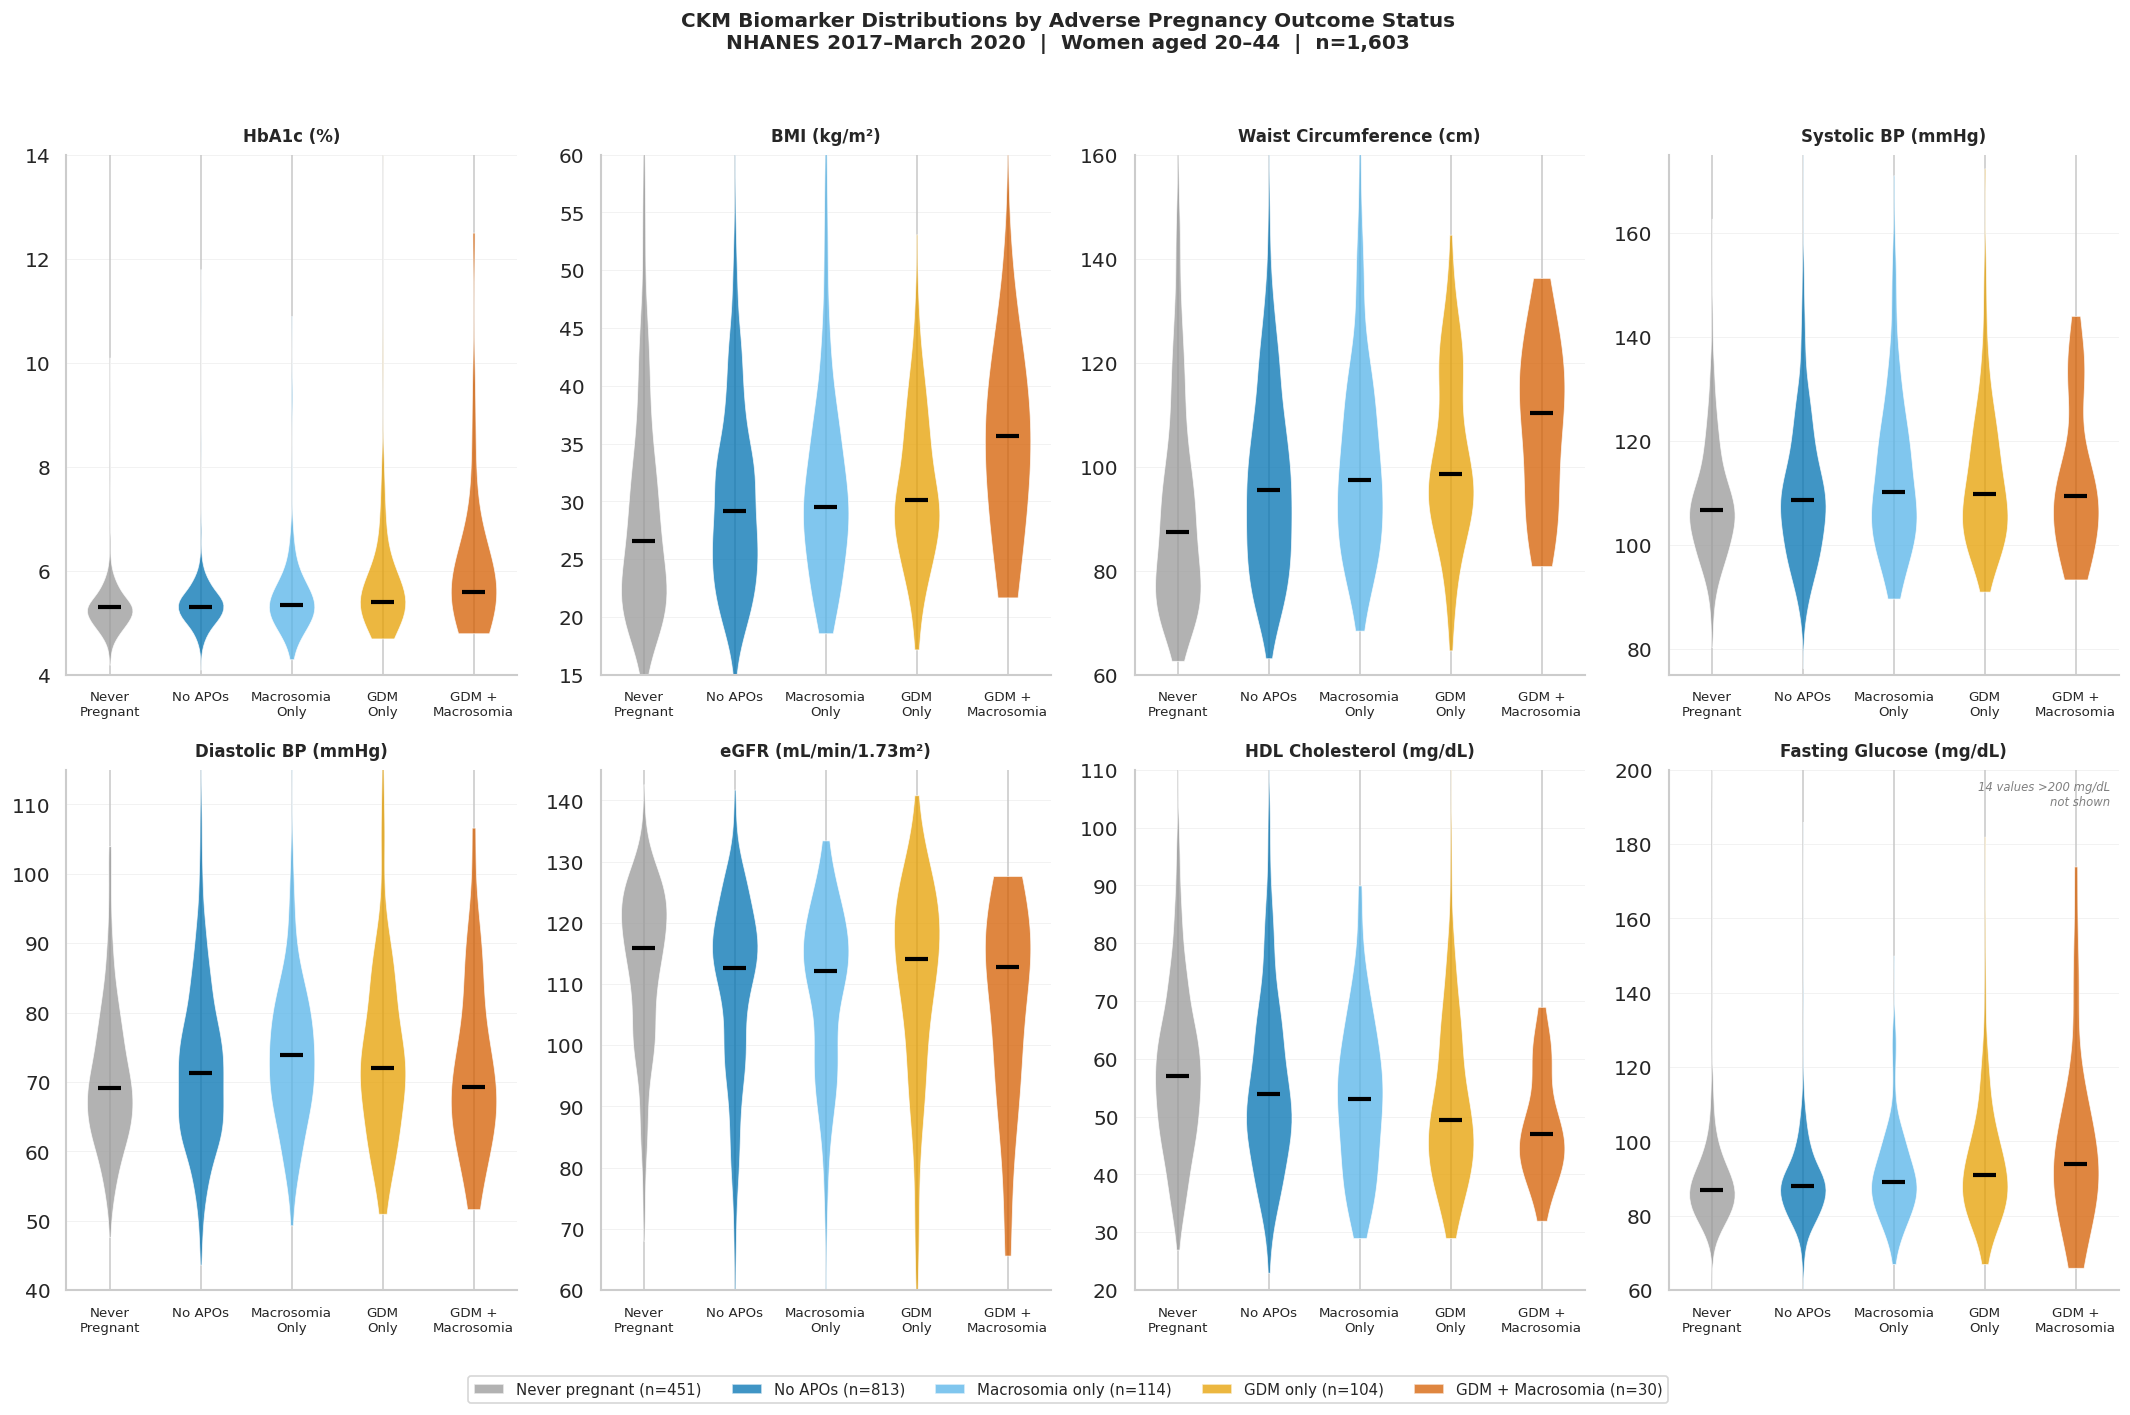

✓ Figure saved: biomarker_distributions_by_apo.png
  Note: 14 glucose values >200 mg/dL excluded from display only — not from analysis


In [5]:
# ── Biomarker distributions by APO status — improved ──────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 11))
axes = axes.flatten()

# Y-axis limits to improve readability
y_limits = {
    'HbA1c':    (4.0,  14.0),
    'BMI':      (15.0, 60.0),
    'Waist':    (60.0, 160.0),
    'Mean_SBP': (75.0, 175.0),
    'Mean_DBP': (40.0, 115.0),
    'eGFR':     (60.0, 145.0),
    'HDL':      (20.0, 110.0),
    'Glucose':  (60.0, 200.0),   # capped at 200 — extreme outliers excluded
}

# Note for glucose cap
glucose_n_excluded = (df['Glucose'] > 200).sum()

for i, (feat, label) in enumerate(biomarker_labels.items()):
    ax = axes[i]

    plot_data   = []
    plot_colors = []
    n_labels    = []

    for sg, color in zip(subgroup_plot_order, subgroup_colors):
        values = df.loc[apo_labels[sg], feat].dropna().values
        # Cap glucose for display only — does not affect data
        if feat == 'Glucose':
            values = values[values <= 200]
        plot_data.append(values)
        plot_colors.append(color)
        n_labels.append(f'n={len(values)}')

    # Violin plot
    parts = ax.violinplot(plot_data,
                          positions=range(len(plot_data)),
                          showmedians=True,
                          showextrema=False)

    for pc, color in zip(parts['bodies'], plot_colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.75)
        pc.set_edgecolor('white')
        pc.set_linewidth(0.5)

    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2.5)

    # X-axis labels
    ax.set_xticks(range(len(subgroup_plot_labels)))
    ax.set_xticklabels(subgroup_plot_labels, fontsize=8)

    # Title — no redundant y-axis label
    ax.set_title(label, fontsize=10, fontweight='bold', pad=8)
    ax.set_ylabel('')

    # Y-axis limits
    if feat in y_limits:
        ax.set_ylim(y_limits[feat])

    # Add glucose cap note
    if feat == 'Glucose' and glucose_n_excluded > 0:
        ax.text(0.98, 0.98,
                f'{glucose_n_excluded} values >200 mg/dL\nnot shown',
                transform=ax.transAxes,
                ha='right', va='top',
                fontsize=7, color='gray', style='italic')

    # Clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)

# ── Legend ─────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['never_preg'], alpha=0.75,
          label=f'Never pregnant (n=451)'),
    Patch(facecolor=COLORS['no_apo'],     alpha=0.75,
          label=f'No APOs (n=813)'),
    Patch(facecolor=COLORS['macs_only'],  alpha=0.75,
          label=f'Macrosomia only (n=114)'),
    Patch(facecolor=COLORS['gdm_only'],   alpha=0.75,
          label=f'GDM only (n=104)'),
    Patch(facecolor=COLORS['gdm_macs'],   alpha=0.75,
          label=f'GDM + Macrosomia (n=30)'),
]

fig.legend(handles=legend_elements,
           loc='lower center',
           ncol=5,
           fontsize=9,
           framealpha=0.9,
           edgecolor='lightgray',
           bbox_to_anchor=(0.5, -0.04))

# ── Title ──────────────────────────────────────────────────────────────────
fig.suptitle(
    'CKM Biomarker Distributions by Adverse Pregnancy Outcome Status\n'
    'NHANES 2017–March 2020  |  Women aged 20–44  |  n=1,603',
    fontsize=12, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(FIG_DIR / 'biomarker_distributions_by_apo.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print('✓ Figure saved: biomarker_distributions_by_apo.png')
if glucose_n_excluded > 0:
    print(f'  Note: {glucose_n_excluded} glucose values >200 mg/dL '
          f'excluded from display only — not from analysis')

---
## Section 5 · Feature Correlation Analysis

Correlation analysis among the CKM biomarker candidates serves two purposes:

1. **Identify collinear features** — highly correlated features 
   (|r| > 0.7) contribute redundant information to k-means distance 
   calculations, potentially over-weighting certain dimensions
2. **Sanity-check physiological relationships** — biomarkers expected 
   to move together on clinical grounds (e.g. HbA1c and glucose) should 
   show that pattern in the data, confirming the feature matrix behaves 
   as expected before it reaches clustering

### Why Spearman correlation is used rather than Pearson

Two correlation methods are commonly used in data analysis. **Pearson 
correlation** measures the strength of a strictly linear relationship 
between two variables and assumes both are continuous, approximately 
normally distributed, and free of extreme outliers. **Spearman 
correlation** is less restrictive — it measures whether two variables 
move together in the same direction (one increases as the other 
increases, or vice versa) without requiring the relationship to be 
perfectly linear. It does this by replacing raw values with their rank 
order before computing the correlation, making it insensitive to 
extreme outliers and non-normal distributions.

Spearman is the correct choice here for two reasons:

**1. Several biomarkers are right-skewed with extreme outliers.** 
The violin plots in Section 4 show that glucose, HbA1c, and BMI all 
have long right tails driven by women with diabetes or severe obesity. 
A single extreme glucose value of 350 mg/dL can artificially distort 
a Pearson correlation — Spearman is unaffected because it only cares 
about rank order, not raw values.

**2. Not every biomarker relationship is guaranteed to be linear.** 
Clinical relationships between biomarkers (e.g. HbA1c and glucose) are 
often monotonic rather than strictly linear across their full range. 
Pearson correlation assumes a strictly linear relationship — Spearman 
handles monotonic-but-nonlinear relationships naturally.

To summarize, Pearson is more powerful when its assumptions are met. 
Spearman is more appropriate when they are not. In this dataset, Spearman
is more robust to the non-normal distributions and outliers observed in Section 4.

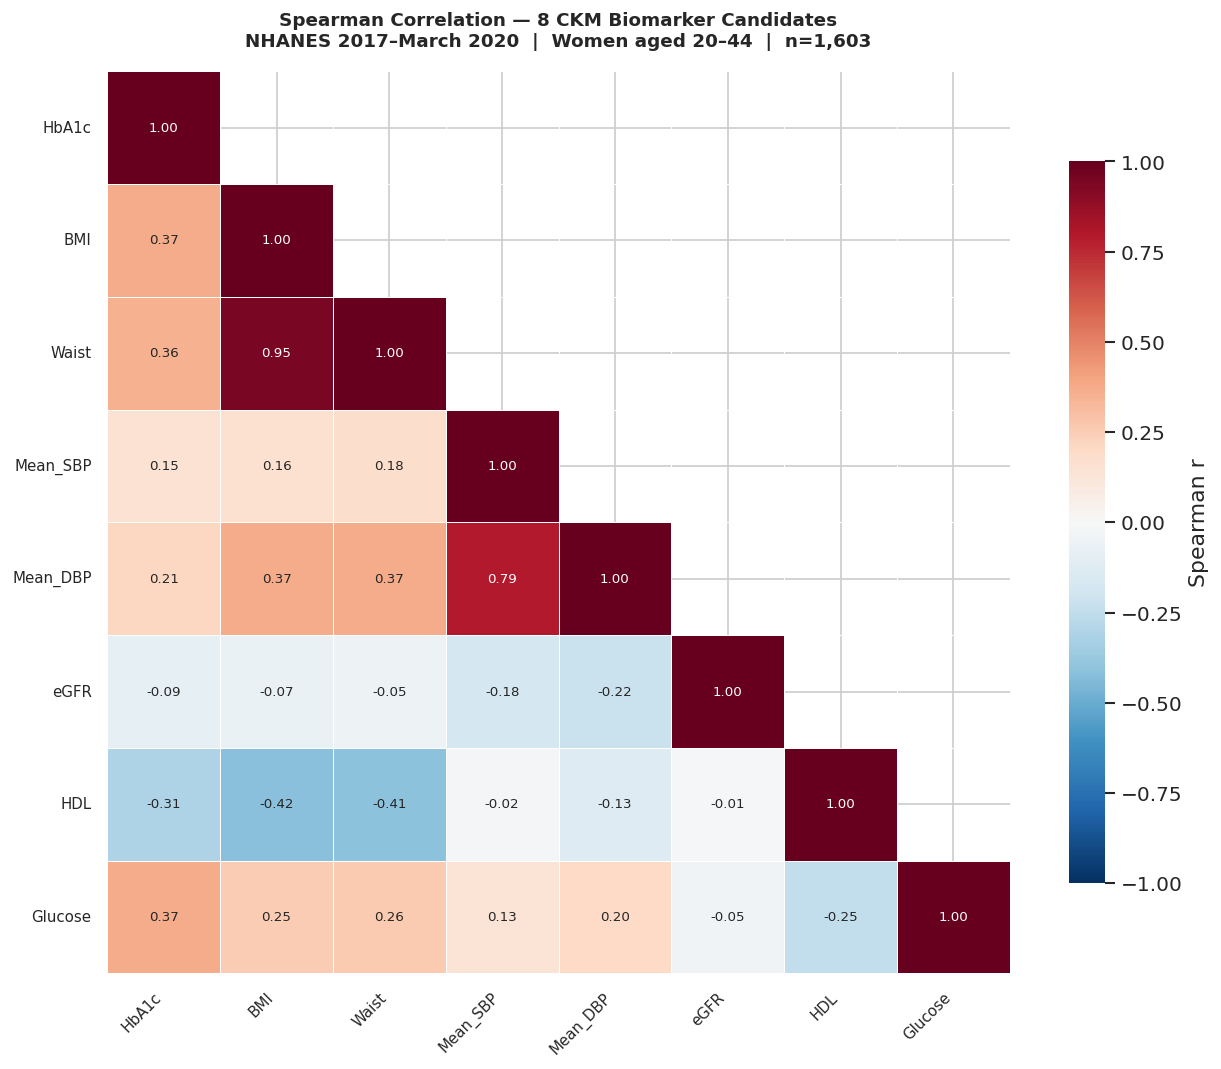

✓ Figure saved: correlation_heatmap.png

High correlations (|r| > 0.5):
  Feature 1       Feature 2            r
  ─────────────── ─────────────── ──────
  BMI             Waist             0.95 ⚠️
  Mean_SBP        Mean_DBP          0.79 ⚠️

  ⚠️  |r| > 0.7 warrants attention for clustering feature selection (notebook 05)


In [6]:
# ── Correlation analysis — CKM biomarker candidates ────────────────────────
# Spearman correlation on complete cases only
# Note: none of the reproductive features carry a 'clustering' label in the
# current design (see notebook 02) — clustering_features therefore resolves
# to the CKM biomarker candidates only (see notebook 03).

corr_features = clustering_features

# Compute Spearman correlation matrix
corr_matrix = df[corr_features].corr(method='spearman')

# ── Heatmap ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 8},
    ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Spearman r'}
)

ax.set_title(
    f'Spearman Correlation — {len(corr_features)} CKM Biomarker Candidates\n'
    'NHANES 2017–March 2020  |  Women aged 20–44  |  n=1,603',
    fontsize=11, fontweight='bold', pad=15
)

# Rotate labels
ax.set_xticklabels(ax.get_xticklabels(),
                   rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(),
                   rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'correlation_heatmap.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Figure saved: correlation_heatmap.png')

# ── Flag high correlations ─────────────────────────────────────────────────
print('\nHigh correlations (|r| > 0.5):')
print(f'  {"Feature 1":<15} {"Feature 2":<15} {"r":>6}')
print(f'  {"─"*15} {"─"*15} {"─"*6}')

for i in range(len(corr_features)):
    for j in range(i+1, len(corr_features)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            flag = ' ⚠️' if abs(r) > 0.7 else ''
            print(f'  {corr_features[i]:<15} {corr_features[j]:<15} '
                  f'{r:>6.2f}{flag}')

print(f'\n  ⚠️  |r| > 0.7 warrants attention for clustering feature selection (notebook 05)')

### Correlation findings

Spearman correlations were computed across the 8 CKM biomarker 
candidates established in notebook 03 (HbA1c, BMI, Waist, Mean_SBP, 
Mean_DBP, eGFR, HDL, Glucose). Reproductive features are not included 
in this matrix — they are not clustering candidates in the current 
design (see notebook 02) and are examined for cluster enrichment 
separately in notebook 07.

**Two feature pairs exceed the |r| > 0.7 collinearity threshold:**

**BMI ↔ Waist (r = 0.95):**
Both capture adiposity but through different measurements. Including 
both would double-weight adiposity in k-means distance calculations, 
risking clusters driven primarily by body size rather than the full 
CKM profile. BMI is retained as the more standard clinical measure; 
Waist is dropped from clustering but retained for descriptive 
characterization.

**Mean_SBP ↔ Mean_DBP (r = 0.79):**
Systolic and diastolic pressure rise together in hypertension — 
including both double-weights the vascular dimension. Mean_SBP is 
retained as the single BP feature for this analysis.

While Mean Arterial Pressure (MAP = (SBP + 2×DBP) / 3) is 
considered a more clinically precise measure of overall tissue 
perfusion and end-organ health, SBP is the established gold standard 
for long-term cardiovascular risk prediction and remains an 
exceptionally strong independent predictor of heart disease and 
stroke. Given that this project's central question concerns early 
cardiometabolic risk in reproductive-age women, SBP is the more 
appropriate single BP feature for clustering. Mean_DBP is dropped 
from the clustering feature set but retained for descriptive 
characterization.

**Features flagged for removal before clustering in notebook 05:**
Waist (collinear with BMI, r = 0.95) and Mean_DBP (collinear with 
Mean_SBP, r = 0.79) will be dropped at the start of notebook 05, 
reducing the CKM biomarker clustering candidates from 8 to 6: HbA1c, 
BMI, Mean_SBP, eGFR, HDL, Glucose.

---
## Section 6 · Missingness Analysis

Missing values in this dataset are predominantly structural — they arise 
from NHANES skip logic rather than data collection failure. Before any 
imputation is applied in notebook 05, the source and extent of missingness 
must be characterized for each clustering feature.

### Sources of missingness

**Never-pregnant women (n=451, 28.1% of sample):**
Women who reported never having been pregnant were not administered 
pregnancy-related questions. Their NaN values on Parity, Pregnancy_Loss, 
and APO_Score are not missing data — they are clinically meaningful zeros. 
A woman who has never been pregnant has zero deliveries, zero pregnancy 
losses, and zero adverse pregnancy outcomes by definition. These will be 
zero-imputed in notebook 05 using Ever_Pregnant == 0 as the gate variable.

**Ever-pregnant women with item non-response:**
After accounting for never-pregnant women, a smaller subset of ever-pregnant 
women have missing values on pregnancy features due to item non-response — 
they were asked the questions but did not answer. The diagnostic below 
quantifies this residual missingness.

**Age_Menarche — random item non-response:**
78 women (4.9%) are missing Age_Menarche. This missingness is not tied to 
any skip logic condition and is treated as missing at random.

Age_Menarche is a descriptive and exposure variable in this pipeline, not 
a clustering input, so the usual case for KNN or model-based imputation — 
avoiding artificial variance compression in a feature that feeds distance 
calculations — doesn't apply here. It also cuts the other way: if these 
78 values were imputed using the CKM biomarkers as the neighbor space, the 
imputed values would be pulled toward whatever biomarker profile each 
woman already has, which would manufacture part of the very cluster-level 
difference notebook 07 later measures. Notebook 05 leaves Age_Menarche 
unimputed and excludes only the 78 missing women from analyses that use 
it directly.

In [7]:
# ── Residual missingness after zero-imputing never-pregnant women ──────────
# Ever_Pregnant == 0 → Parity, Pregnancy_Loss, APO_Score are structurally zero
# Any remaining NaN on these features belongs to ever-pregnant women only

never_pregnant_mask = df['Ever_Pregnant'] == 0
ever_pregnant_mask  = df['Ever_Pregnant'] == 1

print('=== Residual Missingness Diagnostic ===\n')
print(f'  Never-pregnant women:  {never_pregnant_mask.sum():,}')
print(f'  Ever-pregnant women:   {ever_pregnant_mask.sum():,}')

pregnancy_features = ['Parity', 'Pregnancy_Loss', 'APO_Score']

print(f'\n  NaN among ever-pregnant women (before zero-impute):')
for feat in pregnancy_features:
    n_nan = df.loc[ever_pregnant_mask, feat].isna().sum()
    pct   = n_nan / ever_pregnant_mask.sum() * 100
    print(f'    {feat:<20} {n_nan:>4} NaN  ({pct:.1f}%)')

=== Residual Missingness Diagnostic ===

  Never-pregnant women:  451
  Ever-pregnant women:   1,150

  NaN among ever-pregnant women (before zero-impute):
    Parity                 15 NaN  (1.3%)
    Pregnancy_Loss         50 NaN  (4.3%)
    APO_Score              89 NaN  (7.7%)


### Missingness strategy for notebook 05

Based on the diagnostic above, the following strategies will be applied 
before clustering. Only the CKM biomarkers below are actual clustering 
inputs — the reproductive features are coded for descriptive and exposure 
purposes and held out of the clustering algorithm entirely:

**Parity — 15 NaN among ever-pregnant women (1.3%):**
Small residual missingness from item non-response. Median imputation 
applied within ever-pregnant women. The 451 never-pregnant women receive 
Parity = 0 by clinical definition.

**Pregnancy_Loss — 50 NaN among ever-pregnant women (4.3%):**
Residual missingness from incomplete Gravidity or Parity responses, 
preventing Pregnancy_Loss calculation. Median imputation applied within 
ever-pregnant women. The 451 never-pregnant women receive 
Pregnancy_Loss = 0 by clinical definition.

**APO_Score — 89 NaN among ever-pregnant women (7.7%):**
These women were asked about gestational diabetes and macrosomia but did 
not answer. APO_Score cannot be imputed — it encodes discrete clinical 
events (GDM, macrosomia) that either occurred or did not. Assigning a 
statistical estimate to unknown pregnancy outcomes is clinically 
indefensible.

Because APO_Score is a descriptive/exposure variable rather than a 
clustering input, an unknown APO status is not a reason to exclude a 
woman from clustering — her CKM biomarkers are unaffected by whether she 
answered the GDM/macrosomia questions. These 89 women are flagged, not 
excluded, and remain eligible for clustering in notebook 05 if their 
biomarker data is complete. They are excluded only from notebook 07's 
enrichment test, which specifically requires a known APO status.

**Age_Menarche — 78 NaN (4.9%):**
Left unimputed, as described above — excluded only from analyses that 
use Age_Menarche directly.

**CKM biomarkers — missingness handled by available data:**
Missing biomarker values reflect women who did not complete a given 
examination module. These are not imputed — k-means will be run on 
available complete cases after the reproductive feature imputation steps 
above are applied. The impact on effective sample size is quantified 
at the start of notebook 05.

---
## Section 7 · Medication Confounders

Several medications directly modify the CKM biomarkers used for clustering,
potentially masking the true underlying cardiometabolic risk profile of a 
woman at the time of measurement. A woman on metformin will have lower 
glucose and HbA1c than her untreated baseline; a woman on antihypertensives 
will have lower blood pressure; a woman on statins will have higher HDL and 
lower LDL than without treatment.

If medicated women are included in clustering without any adjustment, their 
biomarker values reflect treatment effect rather than underlying disease 
burden. This risks misclassifying women with significant CKM dysregulation 
into low-risk clusters simply because their medications are working.

The following medication flags were engineered in notebook 03:

- **On_Metformin** — directly lowers glucose and HbA1c; strongly 
  associated with GDM history and insulin resistance
- **On_Statin** — modifies HDL and LDL; associated with dyslipidemia 
  and cardiovascular risk
- **On_Antihypertensive** — lowers blood pressure; masks hypertension 
  in Mean_SBP
- **On_Insulin** — lowers glucose and HbA1c; indicates advanced glucose 
  dysregulation
- **On_Hormonal_Contraception** — modifies lipid profile and blood 
  pressure; common in reproductive-age women

### Prevalence in the analytical sample

The cell below quantifies how many women in each APO subgroup are on 
each medication class. This determines whether medication use is 
concentrated in the APO-positive groups — which would confound the 
clustering — or distributed broadly across the sample.

In [8]:
# ── Medication confounder prevalence by APO status ─────────────────────────
med_flags = [
    'On_Metformin',
    'On_Statin', 
    'On_Antihypertensive',
    'On_Insulin',
    'On_Hormonal_Contraception',
    'Any_Prescription',
]

subgroups = {
    'Never pregnant': df['Ever_Pregnant'] == 0,
    'No APOs':        df['APO_Score'] == 0,
    'Macs only':      df['APO_Score'] == 1,
    'GDM only':       df['APO_Score'] == 2,
    'GDM + Macs':     df['APO_Score'] == 3,
    'Overall':        pd.Series(True, index=df.index),
}

print('=== Medication Prevalence by APO Status (%) ===\n')
print(f'  {"Medication":<26}', end='')
for sg in subgroups:
    print(f' {sg:>14}', end='')
print()
print(f'  {"─"*26}', end='')
for _ in subgroups:
    print(f' {"─"*14}', end='')
print()

for med in med_flags:
    if med not in df.columns:
        continue
    print(f'  {med:<26}', end='')
    for sg, mask in subgroups.items():
        n_sg  = mask.sum()
        n_med = df.loc[mask, med].sum()
        pct   = n_med / n_sg * 100 if n_sg > 0 else 0
        print(f' {n_med:>5} ({pct:>4.1f}%)', end='')
    print()

print(f'\n  n =                          ', end='')
for sg, mask in subgroups.items():
    print(f' {mask.sum():>14,}', end='')
print()

=== Medication Prevalence by APO Status (%) ===

  Medication                 Never pregnant        No APOs      Macs only       GDM only     GDM + Macs        Overall
  ────────────────────────── ────────────── ────────────── ────────────── ────────────── ────────────── ──────────────
  On_Metformin                14.0 ( 3.1%)  11.0 ( 1.4%)   4.0 ( 3.5%)  13.0 (12.5%)   1.0 ( 3.3%)  48.0 ( 3.0%)
  On_Statin                    0.0 ( 0.0%)   8.0 ( 1.0%)   2.0 ( 1.8%)   8.0 ( 7.7%)   3.0 (10.0%)  22.0 ( 1.4%)
  On_Antihypertensive         23.0 ( 5.1%)  58.0 ( 7.1%)   9.0 ( 7.9%)  16.0 (15.4%)   4.0 (13.3%) 116.0 ( 7.2%)
  On_Insulin                   1.0 ( 0.2%)   4.0 ( 0.5%)   3.0 ( 2.6%)   5.0 ( 4.8%)   3.0 (10.0%)  16.0 ( 1.0%)
  On_Hormonal_Contraception   98.0 (21.7%)  43.0 ( 5.3%)   9.0 ( 7.9%)   7.0 ( 6.7%)   1.0 ( 3.3%) 173.0 (10.8%)
  Any_Prescription           206.0 (45.7%) 306.0 (37.6%)  44.0 (38.6%)  56.0 (53.8%)  16.0 (53.3%) 670.0 (41.8%)

  n =                             

### Medication confounder decision

Medication use is not randomly distributed across the analytical sample
— it is concentrated precisely in APO-positive women, the primary exposure
group of this analysis. Women with GDM history are on metformin at 9× the 
rate of no-APO women (12.5% vs 1.4%), on statins at 7–10× the rate (7.7–10.0%
vs 1.0%), and on antihypertensives at approximately 2× the rate (13.3–15.4% vs
7.1%). Looking across all five CKM-relevant medication classes together, 30.8%
of GDM-only and 30.0% of GDM + macrosomia women are on at least one — more than
double the 13.8% rate among women with no APOs.

This concentration of medication use in the highest-risk group creates an 
important interpretive consideration. These women are on treatment *because* 
they have cardiometabolic disease — their medicated biomarker values still 
reflect underlying risk, albeit attenuated. A woman with HbA1c of 6.8% on 
metformin almost certainly had higher untreated values. Excluding her does 
not produce a cleaner analysis — it produces a biased one that systematically 
removes the highest-risk APO-positive women from the very analysis designed 
to detect their risk profile.

**Decision: retain all medicated women in the primary analysis.**

Medication flags (On_Metformin, On_Statin, On_Antihypertensive, On_Insulin, 
On_Hormonal_Contraception) are carried forward as descriptive covariates. 
In notebook 07, cluster profiles will be characterized alongside medication 
prevalence so that biomarker values can be interpreted in the appropriate 
clinical context — a cluster with elevated HbA1c and high metformin 
prevalence signals more severe underlying dysregulation than the biomarker 
value alone suggests.

**Sensitivity analysis:** Clustering will be repeated in notebook 06 
excluding women on metformin, insulin, or antihypertensives (n excluded = 
to be determined at start of notebook 05) to confirm that the primary 
cluster structure is not an artifact of treatment-modified biomarker values. 
Agreement between primary and sensitivity cluster assignments will be 
reported.

---
## Section 8 · Notebook Summary & Handoff to Notebook 05

This notebook characterized the complete CKM feature matrix across 1,603 
reproductive-age women aged 20–44. The findings below directly define the 
preprocessing and clustering design implemented in notebook 05.

### Analytical sample
- 1,603 women aged 20–44, NHANES 2017–March 2020
- 451 (28.1%) never-pregnant, 1,150 (71.9%) ever-pregnant
- APO distribution: 813 no APOs (50.7%), 114 macrosomia only (7.1%), 
  104 GDM only (6.5%), 30 GDM + macrosomia (1.9%)

### Decisions made in this notebook

**Feature collinearity (Section 5):**
- Waist dropped — collinear with BMI (r = 0.95)
- Mean_DBP dropped — collinear with Mean_SBP (r = 0.79)
- Final clustering feature set: 6 CKM biomarkers only
  (HbA1c, BMI, Mean_SBP, eGFR, HDL, Glucose)

Age_Menarche, Parity, Pregnancy_Loss, and APO_Score are **not** part of 
the clustering feature set. They're carried forward as descriptive and 
exposure variables for notebook 07 to test against the clusters that 
notebook 06 builds from biomarkers alone.

**Missingness strategy (Section 6):**
- Never-pregnant women → Parity = 0, Pregnancy_Loss = 0, APO_Score = 0 
  (clinical definition, not statistical imputation)
- Parity 15 NaN + Pregnancy_Loss 50 NaN among ever-pregnant → median 
  imputation
- APO_Score 89 NaN among ever-pregnant → flagged, not excluded. Since 
  APO_Score isn't a clustering input, an unknown APO status is no longer 
  a reason to drop a woman from clustering — she's excluded only from 
  notebook 07's enrichment test, which needs a known status
- Age_Menarche 78 NaN → left unimputed. KNN imputation was the original 
  plan when Age_Menarche was still a clustering feature; imputing it from 
  the same biomarkers it would later be compared against would manufacture 
  part of the cluster-level difference notebook 07 measures
- Clustering eligibility depends only on complete data across the 6 CKM 
  biomarkers → primary clustering sample: n = 1,358 (1,603 − 245 with 
  incomplete biomarker data)

**Medication confounders (Section 7):**
- All medicated women retained in primary analysis — exclusion would 
  introduce selection bias against the highest-risk APO-positive women
- Medication flags carried forward as descriptive covariates for cluster 
  characterization in notebook 07
- Sensitivity analysis: re-run clustering excluding women on metformin, 
  insulin, or antihypertensives

### What notebook 05 will do

1. Code the reproductive/exposure variables per the missingness strategy 
   above, entirely separately from the CKM biomarker matrix
2. Drop Waist and Mean_DBP, finalizing the 6-feature CKM biomarker 
   clustering set
3. Scale the 6 clustering features (robust scaling — rationale in 
   notebook 05)
4. Export the biomarker-only clustering matrix for notebook 06, and a 
   separate reference of women with unknown APO status for notebook 07 
   to exclude from its enrichment test

### What notebook 06 will do

5. Execute k-means clustering across k = 2–8 on the 6 CKM biomarkers
6. Identify and exclude an extreme-glycemia outlier phenotype before 
   finalizing k selection
7. Select k based on internal validity metrics and clinical 
   interpretability (see notebook 06 for the disclosed k=2-vs-k=3 
   tradeoff)
8. Export cluster assignments for a genuinely non-circular enrichment 
   test in notebook 07
